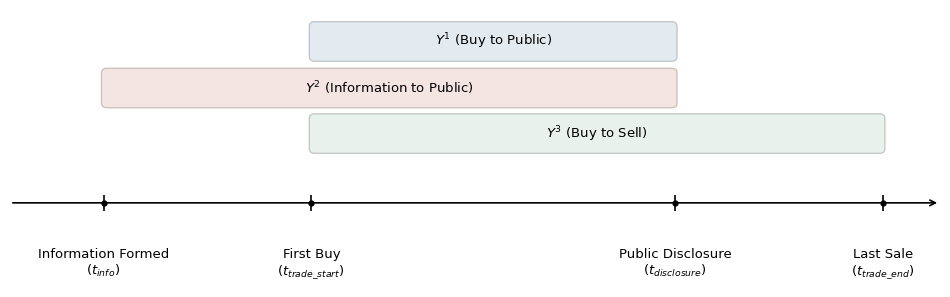

Saved to: /root/autodl-tmp/Figure1/insider_trading_labels.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_insider_trading_schema(save_path="/root/autodl-tmp/Figure1/insider_trading_labels.png"):
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=(12, 3.6))  # 略微压缩高度

    nodes = {"T1": 1.5, "T2": 3.5, "T3": 7.0, "T4": 9.0}
    node_labels = {
        "T1": "Information Formed\n($t_{info}$)",
        "T2": "First Buy\n($t_{trade\\_start}$)",
        "T3": "Public Disclosure\n($t_{disclosure}$)",
        "T4": "Last Sale\n($t_{trade\\_end}$)",
    }

    y_axis = 0.0
    left_margin = 0.9
    right_margin = 0.55
    x_left = nodes["T1"] - left_margin
    x_right = nodes["T4"] + right_margin

    # 时间轴（线条更细）
    ax.annotate(
        "", xy=(x_right, y_axis), xytext=(x_left, y_axis),
        arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
        zorder=1
    )

    # 节点
    for key, x in nodes.items():
        ax.vlines(x, y_axis - 0.08, y_axis + 0.08, lw=1.2, color="black", zorder=2)
        ax.plot(x, y_axis, marker="o", markersize=3.5, color="black", zorder=3)
        ax.text(x, y_axis - 0.45, node_labels[key],
                ha="center", va="top",
                fontsize=9.5, fontweight="normal", color="black")

    # 彩条参数
    h = 0.36
    y_set1, y_set2, y_set3 = 1.45, 0.98, 0.52

    EDGE_GRAY = "#666666"

    def rounded_bar(x0, x1, y, h, facecolor, text):
        bar = patches.FancyBboxPatch(
            (x0, y), x1 - x0, h,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            linewidth=0.9,
            facecolor=facecolor,
            edgecolor=EDGE_GRAY,
            alpha=0.35   # 降低透明度，更轻
        )
        ax.add_patch(bar)
        ax.text((x0 + x1) / 2, y + h / 2, text,
                ha="center", va="center",
                fontsize=9.5, fontweight="normal",
                color="black")

    # 更低饱和度
    FACE_SET1 = "#AFC6D9"
    FACE_SET2 = "#E3B5AE"
    FACE_SET3 = "#BFD8C6"

    rounded_bar(nodes["T2"], nodes["T3"], y_set1, h,
                FACE_SET1, r"$Y^{1}$ (Buy to Public)")
    rounded_bar(nodes["T1"], nodes["T3"], y_set2, h,
                FACE_SET2, r"$Y^{2}$ (Information to Public)")
    rounded_bar(nodes["T2"], nodes["T4"], y_set3, h,
                FACE_SET3, r"$Y^{3}$ (Buy to Sell)")

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(-0.85, 1.95)
    ax.axis("off")

    plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    print(f"Saved to: {save_path}")

generate_insider_trading_schema()
